c:\Users\Daniel\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


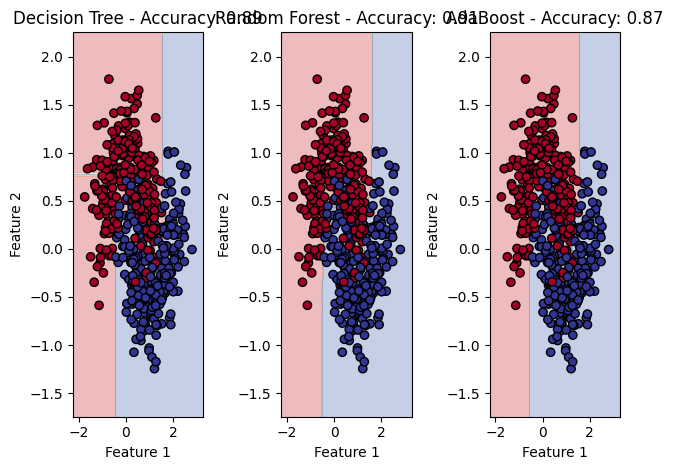

------------------------------
Reporte de Precision:
------------------------------
Decision Tree: 0.8933
Random Forest: 0.9067
AdaBoost: 0.8733


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline

def plot_decision_boundary(model, X, y, title, accuracy):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdYlBu", edgecolors="k")
    plt.title(f"{title} - Accuracy: {accuracy:.2f}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

def run_ensemble_demo():
    X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=5),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "AdaBoost": AdaBoostClassifier(n_estimators=100, algorithm="SAMME", random_state=42)
    }

    results = {}
    for i, (name, model) in enumerate(models.items(), 1):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc  # Fixed: Stores the numeric value instead of the function reference

        plt.subplot(1, 3, i)
        plot_decision_boundary(model, X, y, name, acc)  # Fixed: Corrected plt.decision_boundary to the local function

    plt.tight_layout()
    plt.show()

    print("-"*30)
    print("Reporte de Precision:")
    print("-"*30)
    for name, acc in results.items():
        print(f"{name}: {acc:.4f}")

run_ensemble_demo()